# Praktikum 1 Data Mining RKA (N)

**Nama:** [Isi Nama]

**NRP:** [Isi NRP]

Template Kaggle Competition Praktikum Data Mining RKA.

## Setup

In [463]:
# Import Library
import os
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
# tambahan library yang mungkin diperlukan
#
#

## Load Data

In [464]:
df = pd.read_csv('train.csv')
df_test = pd.read_csv('test.csv')


## Exploratory Data Analysis

EDA dilakukan untuk memahami ukuran data, tipe kolom, duplikasi, missing value, distribusi target, dan hubungan antar fitur numerik sebelum preprocessing.

In [465]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8205 entries, 0 to 8204
Data columns (total 33 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   id                            8205 non-null   int64  
 1   model_year                    8205 non-null   int64  
 2   maker                         8205 non-null   str    
 3   model_family                  8205 non-null   str    
 4   trim                          8112 non-null   str    
 5   listing_city                  8205 non-null   str    
 6   listing_state                 8205 non-null   str    
 7   odometer_reading              8205 non-null   int64  
 8   body_color                    7980 non-null   str    
 9   cabin_color                   8000 non-null   str    
 10  city_mpg                      7681 non-null   float64
 11  highway_mpg                   7672 non-null   float64
 12  engine_spec                   8125 non-null   str    
 13  gearbox       

In [466]:
missing_summary = df.isna().sum().sort_values(ascending=False)
missing_summary = missing_summary[missing_summary > 0]
display(missing_summary.to_frame('jumlah_missing'))

,jumlah_missing
mpg_spread,658
combined_mpg,658
highway_mpg,533
city_mpg,524
body_color,225
cabin_color,205
cylinder_count,190
engine_displacement_l,175
trim,93
engine_spec,80


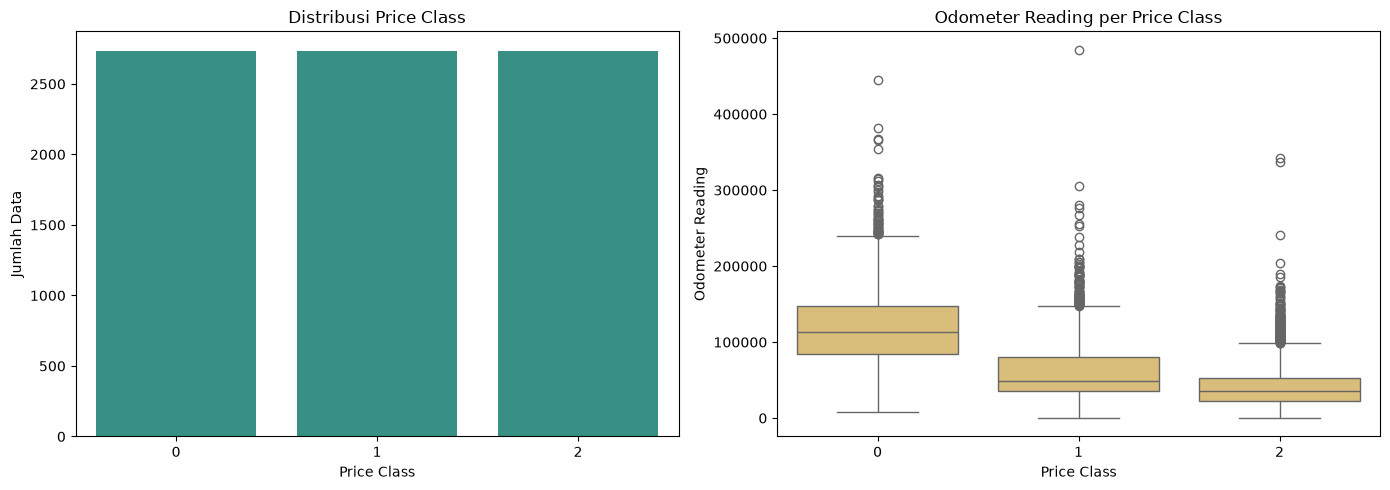

In [467]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=df, x='price_class', ax=axes[0], color='#2a9d8f')
axes[0].set_title('Distribusi Price Class')
axes[0].set_xlabel('Price Class')
axes[0].set_ylabel('Jumlah Data')

sns.boxplot(data=df, x='price_class', y='odometer_reading', ax=axes[1], color='#e9c46a')
axes[1].set_title('Odometer Reading per Price Class')
axes[1].set_xlabel('Price Class')
axes[1].set_ylabel('Odometer Reading')

plt.tight_layout()
plt.show()

Korelasi fitur numerik terhadap price_class:


,korelasi
price_class,1.000000
model_year,0.583182
has_backup_camera,0.262778
turbo_flag,0.247098
equipment_count,0.236723
has_navigation,0.148639
has_heated_seats,0.141821
has_bluetooth,0.139791
engine_displacement_l,0.130588
cylinder_count,0.113771


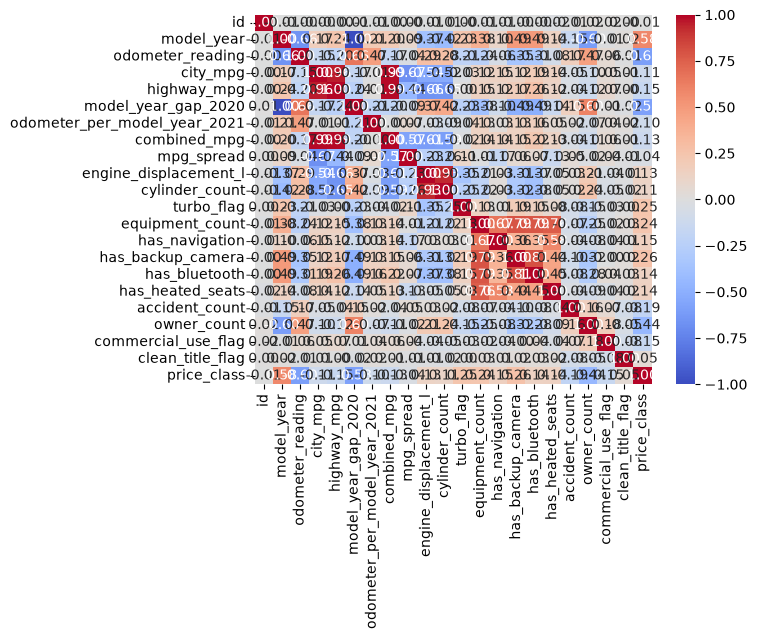

In [468]:
numeric_df = df.select_dtypes(include=np.number)
correlation = numeric_df.corr(numeric_only=True)['price_class'].sort_values(ascending=False)
print('Korelasi fitur numerik terhadap price_class:')
display(correlation.to_frame('korelasi'))

sns.heatmap(numeric_df.corr(numeric_only=True), cmap='coolwarm', center=0, annot=True, fmt=".2f")
plt.show()


In [469]:
df.isna().sum()

id                                0
model_year                        0
maker                             0
model_family                      0
trim                             93
listing_city                      0
listing_state                     0
odometer_reading                  0
body_color                      225
cabin_color                     205
city_mpg                        524
highway_mpg                     533
engine_spec                      80
gearbox                           0
drive_layout                      0
energy_source                     0
model_year_gap_2020               0
odometer_per_model_year_2021      0
combined_mpg                    658
mpg_spread                      658
engine_displacement_l           175
cylinder_count                  190
turbo_flag                       80
equipment_count                   0
has_navigation                    0
has_backup_camera                 0
has_bluetooth                     0
has_heated_seats            

In [470]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8205 entries, 0 to 8204
Data columns (total 33 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   id                            8205 non-null   int64  
 1   model_year                    8205 non-null   int64  
 2   maker                         8205 non-null   str    
 3   model_family                  8205 non-null   str    
 4   trim                          8112 non-null   str    
 5   listing_city                  8205 non-null   str    
 6   listing_state                 8205 non-null   str    
 7   odometer_reading              8205 non-null   int64  
 8   body_color                    7980 non-null   str    
 9   cabin_color                   8000 non-null   str    
 10  city_mpg                      7681 non-null   float64
 11  highway_mpg                   7672 non-null   float64
 12  engine_spec                   8125 non-null   str    
 13  gearbox       

## Preprocessing

Lengkapi bagian ini sesuai dengan **Preprocessing Data** yang kalian lakukan

In [471]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8205 entries, 0 to 8204
Data columns (total 33 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   id                            8205 non-null   int64  
 1   model_year                    8205 non-null   int64  
 2   maker                         8205 non-null   str    
 3   model_family                  8205 non-null   str    
 4   trim                          8112 non-null   str    
 5   listing_city                  8205 non-null   str    
 6   listing_state                 8205 non-null   str    
 7   odometer_reading              8205 non-null   int64  
 8   body_color                    7980 non-null   str    
 9   cabin_color                   8000 non-null   str    
 10  city_mpg                      7681 non-null   float64
 11  highway_mpg                   7672 non-null   float64
 12  engine_spec                   8125 non-null   str    
 13  gearbox       

In [ ]:
for column in df.select_dtypes(include='string').columns:
    df[column].fillna(df[column].mode()[0], inplace=True)

for column in df_test.select_dtypes(include='string').columns:
    df_test[column].fillna(df_test[column].mode()[0], inplace=True)

for column in df.select_dtypes(include=np.number).columns:
    df[column].fillna(df[column].mean(), inplace=True)

for column in df_test.select_dtypes(include=np.number).columns:
    df_test[column].fillna(df_test[column].mean(), inplace=True)

df = pd.get_dummies(df, columns=df.select_dtypes(include='object').columns, drop_first=True)
df_test = pd.get_dummies(df_test, columns=df_test.select_dtypes(include='object').columns, drop_first=True)


df.info()


<class 'pandas.DataFrame'>
RangeIndex: 8205 entries, 0 to 8204
Columns: 5515 entries, id to energy_source_Plug-In
dtypes: bool(5493), float64(8), int64(14)
memory usage: 44.4 MB


/var/folders/1w/yqznhsk91cggg4l67976h2tw0000gn/T/ipykernel_3666/3152905951.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df[column].fillna(df[column].mode()[0], inplace=True)
/var/folders/1w/yqznhsk91cggg4l67976h2tw0000gn/T/ipykernel_3666/3152905951.py:5: ChainedAssignmentError: A value is being set on a copy of a DataFrame or 

In [473]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8205 entries, 0 to 8204
Columns: 5515 entries, id to energy_source_Plug-In
dtypes: bool(5493), float64(8), int64(14)
memory usage: 44.4 MB


In [474]:
df_train = df.copy()

X_train = df_train.drop(columns=['price_class'], errors='ignore')
y_train = df_train['price_class']
X_test = df_test.drop(columns=['id'], errors='ignore')

X_train, X_test = X_train.align(X_test, join='outer', axis=1, fill_value=0)

X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

## Modeling 

**DILARANG MENGUBAH CODE!!!!!!!!!!!!**, sesuaikan semua varible yang dibutuhkan.

**Pastikan sudah memiliki variable berikut:**
`X_train, X_val, y_train, y_val -> df_train`

In [475]:
# Modeling using Decision Tree

model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_val)

print(f"Accuracy: {accuracy_score(y_val, y_pred)}")
print(f"Precision: {precision_score(y_val, y_pred, average='macro', zero_division=0)}")
print(f"Recall: {recall_score(y_val, y_pred, average='macro', zero_division=0)}")
print(f"F1: {f1_score(y_val, y_pred, average='macro', zero_division=0)}")
print(classification_report(y_val, y_pred, zero_division=0))

Accuracy: 0.8238878732480195
Precision: 0.8239134015424563
Recall: 0.8248571885568047
F1: 0.8243443858530567
              precision    recall  f1-score   support

           0       0.85      0.87      0.86       521
           1       0.75      0.74      0.75       560
           2       0.86      0.87      0.87       560

    accuracy                           0.82      1641
   macro avg       0.82      0.82      0.82      1641
weighted avg       0.82      0.82      0.82      1641



# Submission

**DILARANG MENGUBAH CODE!!!!!!!!!!!**

**Pastikan memiliki variable berikut:**
`X_test -> df_test`

In [476]:
id = df_test['id'].tolist()

y_test = model.predict(X_test)
submission_df = pd.DataFrame({'id': id, 'price': y_test})
submission_df.to_csv('submission.csv', index=False)